# Ekstraksi Facial Landmarks SMIC (untuk Graph Convolutional Network)

**Letak di peta:** menulis `../dataset/stgcn_smic_landmarks/` (bukan di dalam `stgcn/`) karena landmark SMIC dipakai bersama notebook training di folder yang sama via path relatif `../dataset/...`.

Notebook ini mengubah setiap klip mikro-ekspresi SMIC menjadi **data graf** untuk GCN.

Berbeda dengan CNN/ViT yang memakai piksel, GCN membutuhkan **Node** (titik) dan **Edge** (relasi antar titik). Di sini 468 titik Face Mesh dari `mediapipe` diperlakukan sebagai Node.

Pipeline:

1. Siapkan folder keluaran `../dataset/stgcn_smic_landmarks/{Negative,Positive,Surprise}`
2. Ambil indeks klip dari `micro_df` (atau bangun ulang dari folder HS/micro)
3. Uniform sampling `np.linspace` menjadi tepat **16 frame** per klip
4. Deteksi 468 landmark per frame dengan **MediaPipe Face Mesh**
5. Fallback ke frame sebelumnya jika deteksi gagal
6. Simpan array `(16, 468, 3)` sebagai `{nama_klip}.npy`
7. Sanity check: scatter plot 468 titik dari frame pertama

## Bentuk tensor akhir

Setiap klip menghasilkan array **`(T=16, V=468, C=3)`**:

| Dimensi | Nama | Arti |
|---------|------|------|
| `T = 16` | **Time** | jumlah frame hasil uniform sampling |
| `V = 468` | **Vertices / Nodes** | titik Face Mesh yang menjadi node graf |
| `C = 3` | **Channels** | koordinat `(x, y, z)` ternormalisasi |

Format `(T, V, C)` ini adalah input standar arsitektur graf spatio-temporal seperti **ST-GCN**.

> Jika `mediapipe` belum terpasang, jalankan di terminal: `pip install mediapipe`


In [1]:
# =============================================================================
# 1. IMPORT, KONFIGURASI PATH, DAN INISIALISASI FACE MESH
# =============================================================================
# Jika mediapipe belum terpasang, jalankan di terminal:  pip install mediapipe
# atau di cell Jupyter:  %pip install mediapipe
import os
import re
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

try:
    import mediapipe as mp
except ImportError as exc:
    raise ImportError(
        'Library mediapipe belum terpasang. Install dulu dengan:\n'
        '  pip install mediapipe\n'
        'atau di Jupyter:\n'
        '  %pip install mediapipe'
    ) from exc

# ==========================================
# KONFIGURASI EKSEKUSI (Lokal vs Server)
# ==========================================
RUN_ON_SERVER = False  # Ubah ke True jika dijalankan di server GPU berkapasitas tinggi

if RUN_ON_SERVER:
    CFG = {
        "epochs": 150,
        "batch_size": 32,
        "use_augmentation": True,
        "patience": 20,
        "num_workers": 4
    }
else:
    CFG = {
        "epochs": 2,
        "batch_size": 4,
        "use_augmentation": False,
        "patience": 2,
        "num_workers": 0
    }

print(f"Mode eksekusi : {'SERVER' if RUN_ON_SERVER else 'LOKAL'}")
print(f"CFG           : {CFG}")

# Root dataset SMIC (folder berisi HS / NIR / VIS)
DATASET_ROOT = Path('../dataset/SMIC_all_cropped').resolve()

# Folder keluaran landmark — sibling dari SMIC_all_cropped
OUTPUT_ROOT = DATASET_ROOT.parent / 'stgcn_smic_landmarks'

# Dimensi tensor graf: (T=16 frame, V=468 node, C=3 koordinat)
NUM_FRAMES = 16          # T — panjang temporal setelah uniform sampling
NUM_LANDMARKS = 468      # V — jumlah node Face Mesh (tanpa refine_landmarks)
NUM_CHANNELS = 3         # C — koordinat (x, y, z)

# Modalitas yang diekstrak. HS adalah standar pada pipeline 3D-CNN / ViT sebelumnya.
TARGET_MODALITY = 'HS'
EMOTION_CLASSES = ['Negative', 'Positive', 'Surprise']

if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(
        f'Folder dataset tidak ditemukan: {DATASET_ROOT}\n'
        'Sesuaikan DATASET_ROOT dengan lokasi SMIC_all_cropped.'
    )

# Inisialisasi Face Mesh:
# - static_image_mode=True  : setiap frame diperlakukan independen (bukan tracking video)
# - max_num_faces=1         : klip SMIC hanya berisi satu wajah
# - refine_landmarks=False  : tetap 468 node (True akan menambah iris menjadi 478)
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=False,
    min_detection_confidence=0.3,   # default 0.5 terlalu ketat pada crop SMIC; 0.3 mengurangi frame kosong
)

print(f'Dataset root : {DATASET_ROOT}')
print(f'Output root  : {OUTPUT_ROOT}')
print(f'Bentuk tensor: (T={NUM_FRAMES}, V={NUM_LANDMARKS}, C={NUM_CHANNELS})')
print(f'Modalitas    : {TARGET_MODALITY}')


/opt/anaconda3/envs/microsense/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset root : /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/SMIC_all_cropped
Output root  : /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/stgcn_smic_landmarks
Bentuk tensor: (T=16, V=468, C=3)
Modalitas    : HS


I0000 00:00:1787664190.207915 1394681 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro


## 2. Setup Direktori Output

Struktur yang dibuat:

```text
dataset/
└── stgcn_smic_landmarks/
    ├── Negative/
    ├── Positive/
    └── Surprise/
```

Setiap sub-folder kelas diisi file `{nama_klip}.npy` berisi array `(16, 468, 3)`.

In [2]:
# =============================================================================
# 2. BUAT FOLDER KELUARAN PER KELAS EMOSI
# =============================================================================
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

class_dirs = {}
for emotion in EMOTION_CLASSES:
    class_dir = OUTPUT_ROOT / emotion
    class_dir.mkdir(parents=True, exist_ok=True)
    class_dirs[emotion] = class_dir
    print(f'Siap: {class_dir}')

print(f'\nFolder Landmark: {OUTPUT_ROOT}')

Siap: /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/stgcn_smic_landmarks/Negative
Siap: /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/stgcn_smic_landmarks/Positive
Siap: /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/stgcn_smic_landmarks/Surprise

Folder Landmark: /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/stgcn_smic_landmarks


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 3. Indeks Klip SMIC

Jika `micro_df` sudah ada di memori kernel (dari `smic_data_discovery.ipynb`), indeks itu dipakai ulang. Jika belum, notebook membangun indeks dari folder `HS/{subjek}/micro/{emosi}/{klip}`.

In [3]:
# =============================================================================
# 3. SIAPKAN DAFTAR KLIP (micro_df ATAU BANGUN ULANG DARI FOLDER)
# =============================================================================
def frame_sort_key(frame_path: Path):
    """Urutkan nama file berdasarkan angka terakhir, bukan alfabet murni.

    Contoh: reg_image9.bmp harus muncul sebelum reg_image10.bmp.
    """
    numbers = re.findall(r'\d+', frame_path.stem)
    return (0, int(numbers[-1])) if numbers else (1, frame_path.name)


def list_clip_frames(clip_dir: str | Path) -> list[Path]:
    """Ambil seluruh frame .bmp di dalam satu folder klip, tersortir numerik."""
    clip_dir = Path(clip_dir)
    frames = [
        path for path in clip_dir.iterdir()
        if path.is_file() and path.suffix.lower() == '.bmp'
    ]
    return sorted(frames, key=frame_sort_key)


def build_hs_micro_index(dataset_root: Path) -> pd.DataFrame:
    """Cari folder klip pada pola */HS/{subjek}/micro/{emosi}/{nama_klip}."""
    records = []
    hs_root = dataset_root / 'HS'
    if not hs_root.is_dir():
        raise FileNotFoundError(f'Folder HS tidak ditemukan: {hs_root}')

    for clip_dir in sorted(hs_root.glob('*/micro/*/*')):
        if not clip_dir.is_dir():
            continue

        frames = list_clip_frames(clip_dir)
        if not frames:
            continue

        emotion_label = clip_dir.parent.name.capitalize()
        if emotion_label not in EMOTION_CLASSES:
            continue

        records.append({
            'sequence_path': str(clip_dir.resolve()),
            'subject_id': clip_dir.parts[-4],
            'emotion_label': emotion_label,
            'sequence_id': clip_dir.name,
            'num_frames': len(frames),
            'modality': 'HS',
            'sample_type': 'Micro',
        })

    return pd.DataFrame(records)


# Pakai micro_df dari notebook discovery jika tersedia; jika tidak, bangun ulang.
if 'micro_df' in globals() and isinstance(micro_df, pd.DataFrame) and not micro_df.empty:
    clip_df = micro_df.copy()
    print('Menggunakan micro_df dari tahap eksplorasi sebelumnya.')
else:
    clip_df = build_hs_micro_index(DATASET_ROOT)
    print('micro_df tidak tersedia di kernel. Indeks klip dibangun dari folder HS/micro.')

# Filter ketat: hanya modalitas target + tiga kelas mikro-ekspresi
clip_df = clip_df[
    (clip_df['modality'] == TARGET_MODALITY)
    & (clip_df['sample_type'] == 'Micro')
    & (clip_df['emotion_label'].isin(EMOTION_CLASSES))
].copy()

if 'sequence_path' not in clip_df.columns:
    raise KeyError('Kolom sequence_path tidak ditemukan pada DataFrame indeks.')

if 'sequence_id' not in clip_df.columns:
    clip_df['sequence_id'] = clip_df['sequence_path'].map(lambda p: Path(p).name)

clip_df = clip_df.reset_index(drop=True)

print(f'\nTotal klip {TARGET_MODALITY}/micro: {len(clip_df)}')
print('Distribusi kelas:')
print(clip_df['emotion_label'].value_counts().reindex(EMOTION_CLASSES))
clip_df.head()

W0000 00:00:1787664190.219499 1394789 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787664190.221628 1394791 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


micro_df tidak tersedia di kernel. Indeks klip dibangun dari folder HS/micro.

Total klip HS/micro: 164
Distribusi kelas:


emotion_label
Negative    70
Positive    51
Surprise    43
Name: count, dtype: int64


,sequence_path,subject_id,emotion_label,sequence_id,num_frames,modality,sample_type
0,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Negative,s1_ne_01,36,HS,Micro
1,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Negative,s1_ne_02,32,HS,Micro
2,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Negative,s1_ne_03,27,HS,Micro
3,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Positive,s1_po_01,23,HS,Micro
4,/Users/stefanieagahari/Micro-Expression-Detect...,s1,Positive,s1_po_02,30,HS,Micro


## 4. Fungsi Ekstraksi Landmark + Fallback

Alur per klip:

1. **Uniform sampling** `np.linspace` memilih tepat 16 indeks merata sepanjang klip
2. Setiap frame dibaca OpenCV (BGR) lalu dikonversi ke **RGB** — MediaPipe hanya menerima RGB
3. Face Mesh menghasilkan 468 landmark dengan `(x, y)` sudah **ternormalisasi 0.0–1.0**

### Kenapa koordinat dibiarkan dalam rasio 0–1?

Klip SMIC punya resolusi crop berbeda-beda. Dengan rasio, model GCN belajar **geometri relatif wajah**, bukan ukuran piksel gambar asli.

### Error handling (fallback)

Wajah SMIC ter-crop sangat ketat sehingga MediaPipe kadang gagal mendeteksi. Strateginya:

- **Gagal di tengah klip** → pakai koordinat dari frame sebelumnya (`last_valid`)
- **Gagal di frame-frame awal** → setelah loop selesai, frame awal di-*backfill* dengan deteksi valid pertama
- **Gagal di seluruh klip** → klip ditandai `no_face` dan tidak disimpan
**Fallback landmark:** jika MediaPipe gagal di satu frame, koordinat **disalin dari frame valid terdekat**. Alasan matematis: tensor harus tetap `(16, 468, 3)` tanpa NaN. Mengisi nol akan membentuk "lubang" di graf yang GraphConv interpretasikan sebagai titik di origin — distorsi geometri yang lebih parah daripada mengulang pose sebelumnya.


In [4]:
# =============================================================================
# 4. UNIFORM SAMPLING + EKSTRAKSI 468 LANDMARK PER KLIP
# =============================================================================
def uniform_sample_indices(num_available: int, num_target: int) -> np.ndarray:
    """Ambil num_target indeks secara merata sepanjang sequence.

    np.linspace menjamin ujung awal dan akhir sequence ikut terwakili.
    Jika num_available < num_target, beberapa frame akan terulang.
    """
    if num_available <= 0:
        raise ValueError('Sequence tidak memiliki frame.')
    if num_available == 1:
        return np.zeros(num_target, dtype=int)

    # Mengambil tepat 16 frame secara proporsional dari total frame video menggunakan np.linspace.
    # Alasan: Model ST-GCN membutuhkan dimensi temporal konstan (T=16) agar ukuran tensor tidak mismatch.
    indices = np.linspace(0, num_available - 1, num=num_target)
    return np.clip(np.round(indices).astype(int), 0, num_available - 1)


def landmarks_to_array(face_landmarks) -> np.ndarray:
    """Ubah hasil Face Mesh menjadi array (468, 3) berisi (x, y, z).

    Nilai x dan y sudah dalam rasio 0.0-1.0 terhadap lebar/tinggi gambar,
    sedangkan z adalah kedalaman relatif terhadap bidang wajah.
    """
    return np.array(
        [[lm.x, lm.y, lm.z] for lm in face_landmarks.landmark],
        dtype=np.float32,
    )[:NUM_LANDMARKS]


def extract_clip_landmarks(clip_folder_path: str | Path) -> dict:
    """Ekstrak tensor graf (T=16, V=468, C=3) dari satu folder klip SMIC.

    Returns
    -------
    dict
        landmarks : np.ndarray (16, 468, 3) atau None jika wajah tidak pernah terdeteksi
        n_detected: jumlah frame yang benar-benar terdeteksi MediaPipe
        n_fallback: jumlah frame yang memakai koordinat frame lain
    """
    clip_dir = Path(clip_folder_path)
    frame_paths = list_clip_frames(clip_dir)
    if not frame_paths:
        raise FileNotFoundError(f'Tidak ada frame .bmp di {clip_dir}')

    sampled_idx = uniform_sample_indices(len(frame_paths), NUM_FRAMES)
    sampled_paths = [frame_paths[i] for i in sampled_idx]

    # Penampung tensor graf: (T=16 frame, V=468 node, C=3 koordinat)
    clip_landmarks = np.zeros(
        (NUM_FRAMES, NUM_LANDMARKS, NUM_CHANNELS), dtype=np.float32
    )

    last_valid = None            # koordinat valid terakhir untuk fallback
    first_valid_position = None  # posisi frame valid pertama (untuk backfill awal)
    n_detected = 0

    for position, frame_path in enumerate(sampled_paths):
        image_bgr = cv2.imread(str(frame_path), cv2.IMREAD_COLOR)
        if image_bgr is None:
            raise IOError(f'Gagal membaca frame: {frame_path}')

        # MediaPipe hanya menerima citra RGB
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        result = face_mesh.process(image_rgb)

        if result.multi_face_landmarks:
            coords = landmarks_to_array(result.multi_face_landmarks[0])
            clip_landmarks[position] = coords
            last_valid = coords
            n_detected += 1
            if first_valid_position is None:
                first_valid_position = position
        elif last_valid is not None:
            # FALLBACK: wajah tidak terdeteksi, pakai koordinat frame sebelumnya.
            # Lebih aman daripada nol: GraphConv akan melihat pose stagnan, bukan titik collapse ke (0,0,0).
            clip_landmarks[position] = last_valid
        # Jika belum ada deteksi sama sekali, biarkan nol dulu lalu di-backfill di bawah

    if first_valid_position is None:
        # Seluruh 16 frame gagal terdeteksi — klip tidak dapat dipakai
        return {'landmarks': None, 'n_detected': 0, 'n_fallback': NUM_FRAMES}

    # Backfill frame-frame awal yang gagal dengan deteksi valid pertama
    if first_valid_position > 0:
        clip_landmarks[:first_valid_position] = clip_landmarks[first_valid_position]

    return {
        'landmarks': clip_landmarks,
        'n_detected': n_detected,
        'n_fallback': NUM_FRAMES - n_detected,
    }


## 5. Eksekusi Batch

Setiap klip valid disimpan ke:

```text
stgcn_smic_landmarks/{kelas}/{nama_klip}.npy
```

Ekstraksi memakai CPU dan memproses 16 frame per klip, jadi prosesnya memerlukan beberapa menit untuk 164 klip.
File `.npy` disimpan di `../dataset/stgcn_smic_landmarks/{Negative,Positive,Surprise}/`. Hierarki kelas ini wajib identik dengan yang dibaca `SMICGraphDataset`.


In [5]:
# =============================================================================
# 5. LOOP EKSTRAKSI LANDMARK SELURUH KLIP SMIC
# =============================================================================
landmark_records = []
n_success = 0
n_failed = 0

for _, row in tqdm(clip_df.iterrows(), total=len(clip_df), desc='Landmark SMIC'):
    clip_path = Path(row['sequence_path'])
    emotion = row['emotion_label']
    clip_name = row['sequence_id']
    save_path = class_dirs[emotion] / f'{clip_name}.npy'

    try:
        result = extract_clip_landmarks(clip_path)

        if result['landmarks'] is None:
            raise RuntimeError('MediaPipe tidak mendeteksi wajah pada seluruh 16 frame')

        # Simpan tensor graf (T=16, V=468, C=3)
        # Simpan (T=16, V=468, C=3) float32. Training nanti permute ke (C, T, V).
        np.save(save_path, result['landmarks'])

        landmark_records.append({
            'sequence_id': clip_name,
            'emotion_label': emotion,
            'sequence_path': str(clip_path),
            'landmark_path': str(save_path),
            'n_detected': result['n_detected'],
            'n_fallback': result['n_fallback'],
            'status': 'ok',
        })
        n_success += 1
    except Exception as exc:
        landmark_records.append({
            'sequence_id': clip_name,
            'emotion_label': emotion,
            'sequence_path': str(clip_path),
            'landmark_path': str(save_path),
            'n_detected': 0,
            'n_fallback': NUM_FRAMES,
            'status': f'error: {exc}',
        })
        n_failed += 1

landmark_index_df = pd.DataFrame(landmark_records)
index_csv = OUTPUT_ROOT / 'landmark_index.csv'
landmark_index_df.to_csv(index_csv, index=False)

ok_rows = landmark_index_df[landmark_index_df['status'] == 'ok']

print(f'\nBerhasil : {n_success}')
print(f'Gagal    : {n_failed}')
print(f'Indeks   : {index_csv}')

if not ok_rows.empty:
    print('\nJumlah file per kelas:')
    print(ok_rows['emotion_label'].value_counts().reindex(EMOTION_CLASSES))
    # Rata-rata frame yang benar-benar terdeteksi menunjukkan seberapa sering fallback dipakai
    print(f"\nRata-rata frame terdeteksi : {ok_rows['n_detected'].mean():.2f} / {NUM_FRAMES}")
    print(f"Rata-rata frame fallback   : {ok_rows['n_fallback'].mean():.2f} / {NUM_FRAMES}")

landmark_index_df.head()


Landmark SMIC:   0%|          | 0/164 [00:00<?, ?it/s]

/opt/anaconda3/envs/microsense/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Landmark SMIC:   1%|          | 2/164 [00:00<00:13, 11.73it/s]

Landmark SMIC:   2%|▏         | 4/164 [00:00<00:14, 11.24it/s]

Landmark SMIC:   4%|▎         | 6/164 [00:00<00:13, 12.00it/s]

Landmark SMIC:   5%|▍         | 8/164 [00:00<00:12, 12.50it/s]

...

Landmark SMIC:  99%|█████████▉| 162/164 [00:12<00:00, 12.44it/s]

Landmark SMIC: 100%|██████████| 164/164 [00:12<00:00, 12.65it/s]

Landmark SMIC: 100%|██████████| 164/164 [00:12<00:00, 12.80it/s]


Berhasil : 164
Gagal    : 0
Indeks   : /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/stgcn_smic_landmarks/landmark_index.csv

Jumlah file per kelas:
emotion_label
Negative    70
Positive    51
Surprise    43
Name: count, dtype: int64

Rata-rata frame terdeteksi : 16.00 / 16
Rata-rata frame fallback   : 0.00 / 16


,sequence_id,emotion_label,sequence_path,landmark_path,n_detected,n_fallback,status
0,s1_ne_01,Negative,/Users/stefanieagahari/Micro-Expression-Detect...,/Users/stefanieagahari/Micro-Expression-Detect...,16,0,ok
1,s1_ne_02,Negative,/Users/stefanieagahari/Micro-Expression-Detect...,/Users/stefanieagahari/Micro-Expression-Detect...,16,0,ok
2,s1_ne_03,Negative,/Users/stefanieagahari/Micro-Expression-Detect...,/Users/stefanieagahari/Micro-Expression-Detect...,16,0,ok
3,s1_po_01,Positive,/Users/stefanieagahari/Micro-Expression-Detect...,/Users/stefanieagahari/Micro-Expression-Detect...,16,0,ok
4,s1_po_02,Positive,/Users/stefanieagahari/Micro-Expression-Detect...,/Users/stefanieagahari/Micro-Expression-Detect...,16,0,ok


## 6. Visualisasi Graf (Sanity Check)

Satu file `.npy` dimuat ulang, lalu 468 titik `(x, y)` dari **frame pertama** ditampilkan sebagai scatter plot.

Sumbu Y dibalik (`invert_yaxis`) karena koordinat citra dihitung dari **atas ke bawah**, sedangkan matplotlib menggambar dari bawah ke atas. Tanpa inversi, wajah akan tampak terbalik.
Sama seperti MMEW: **`invert_yaxis()`** wajib. Tanpa itu wajah graf terbalik dan sanity check menjadi menyesatkan.


Klip contoh    : s1_ne_01 (Negative)
Shape tensor   : (16, 468, 3)  (T=16, V=468, C=3)
Rentang nilai x: -0.117 - 1.103
Rentang nilai y: -0.064 - 1.015


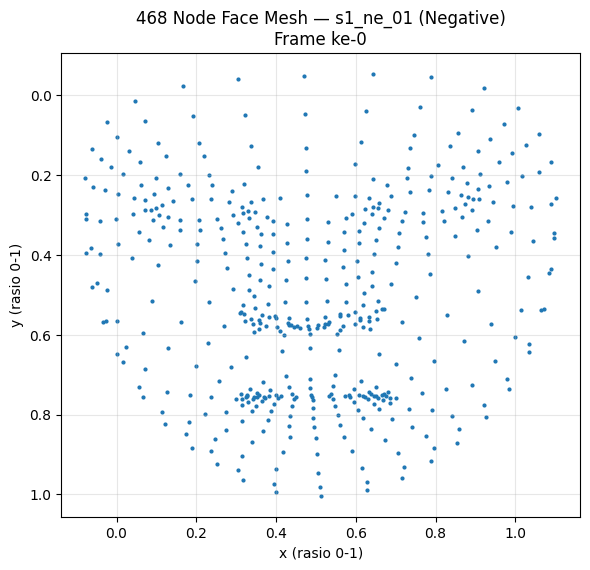

In [6]:
# =============================================================================
# 6. SANITY CHECK: SCATTER PLOT 468 NODE DARI FRAME PERTAMA
# =============================================================================
if ok_rows.empty:
    raise RuntimeError('Tidak ada klip yang berhasil diekstrak untuk visualisasi.')

# Muat kembali file .npy dari klip pertama yang sukses
sample = ok_rows.iloc[0]
sample_landmarks = np.load(sample['landmark_path'])

print(f"Klip contoh    : {sample['sequence_id']} ({sample['emotion_label']})")
print(f"Shape tensor   : {sample_landmarks.shape}  (T={NUM_FRAMES}, V={NUM_LANDMARKS}, C={NUM_CHANNELS})")
print(f"Rentang nilai x: {sample_landmarks[..., 0].min():.3f} - {sample_landmarks[..., 0].max():.3f}")
print(f"Rentang nilai y: {sample_landmarks[..., 1].min():.3f} - {sample_landmarks[..., 1].max():.3f}")

# Ambil frame pertama saja: (468, 3)
first_frame = sample_landmarks[0]
x_coords = first_frame[:, 0]
y_coords = first_frame[:, 1]

plt.figure(figsize=(6, 6))
plt.scatter(x_coords, y_coords, s=4, c='tab:blue')
# invert_yaxis: pada citra digital y=0 di ATAS. Matplotlib default y=0 di BAWAH.
# Tanpa inversi, dahi dan dagu tertukar — wajah Face Mesh tampak terbalik di sidang.
plt.gca().invert_yaxis()   # koordinat citra dihitung dari atas, jadi sumbu Y dibalik
plt.gca().set_aspect('equal')
plt.title(
    f"468 Node Face Mesh — {sample['sequence_id']} ({sample['emotion_label']})\n"
    'Frame ke-0',
    fontsize=12,
)
plt.xlabel('x (rasio 0-1)')
plt.ylabel('y (rasio 0-1)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Tutup Face Mesh

Melepas resource MediaPipe setelah ekstraksi selesai.

In [7]:
# =============================================================================
# 7. LEPAS RESOURCE MEDIAPIPE
# =============================================================================
face_mesh.close()
print('Face Mesh ditutup.')
print(f'\nData graf siap dipakai GCN: {OUTPUT_ROOT}')
print(f'Setiap file .npy berbentuk (T={NUM_FRAMES}, V={NUM_LANDMARKS}, C={NUM_CHANNELS})')

Face Mesh ditutup.

Data graf siap dipakai GCN: /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/stgcn_smic_landmarks
Setiap file .npy berbentuk (T=16, V=468, C=3)
